In [6]:
url = "https://gist.githubusercontent.com/ahcamachod/a572cfcc2527046db93101f88011b26e/raw/ffb13f45a79d31223e645611a119397dd127ee3c/alquiler.csv"
import pandas as pd
import numpy as np

# Read the CSV file from the URL
df = pd.read_csv(url, sep=';') 
# Display the first few rows of the DataFrame
print(df.head())
# type(df)
# df.info()
# df.tail()
# df.describe()
# df.shape

                      Tipo           Colonia  Habitaciones  Garages  Suites  \
0                 Cocineta           Condesa             1        0       0   
1                     Casa           Polanco             2        0       1   
2  Conjunto Comercial/Sala          Santa Fe             0        4       0   
3             Departamento  Centro Histórico             1        0       0   
4             Departamento         Del Valle             1        0       0   

   Area    Valor  Condominio  Impuesto  
0    40   5950.0      1750.0     210.0  
1   100  24500.0         NaN       NaN  
2   150  18200.0     14070.0    3888.5  
3    15   2800.0      1365.0      70.0  
4    48   2800.0       805.0       NaN  


### VALORES PROMEDIOS DE ALQUILER POR TIPO DE INMUEBBLE ###

<Axes: ylabel='Tipo'>

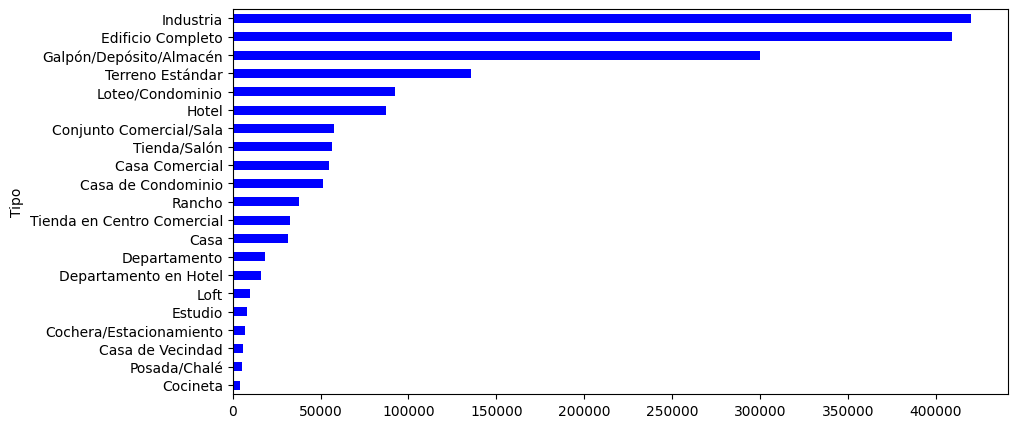

In [7]:
df_group = df.groupby('Tipo')['Valor'].mean().sort_values(ascending=True)
df_group.plot(kind = 'barh', figsize=(10,5),color = 'Blue')

In [8]:
df.Tipo.unique()

array(['Cocineta', 'Casa', 'Conjunto Comercial/Sala', 'Departamento',
       'Casa de Condominio', 'Edificio Completo', 'Departamento en Hotel',
       'Tienda/Salón', 'Casa Comercial', 'Casa de Vecindad',
       'Terreno Estándar', 'Cochera/Estacionamiento', 'Loft',
       'Galpón/Depósito/Almacén', 'Tienda en Centro Comercial', 'Rancho',
       'Posada/Chalé', 'Estudio', 'Hotel', 'Loteo/Condominio',
       'Industria'], dtype=object)

In [9]:
inmuebles_comerciales = ['Conjunto Comercial/Sala','Edificio Completo',
       'Tienda/Salón', 'Casa Comercial','Cochera/Estacionamiento',
       'Galpón/Depósito/Almacén', 'Tienda en Centro Comercial', 'Hotel', 'Loteo/Condominio',
       'Industria','Terreno Estándar']

In [65]:
df_residencial = df.query('@inmuebles_comerciales not in Tipo')
df_residencial.head()

,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
0,Cocineta,Condesa,1,0,0,40,5950.0,1750.0,210.0
1,Casa,Polanco,2,0,1,100,24500.0,NaN,NaN
3,Departamento,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0
4,Departamento,Del Valle,1,0,0,48,2800.0,805.0,NaN
5,Casa de Condominio,Santa Fe,5,4,5,750,77000.0,NaN,NaN


<Axes: ylabel='Tipo'>

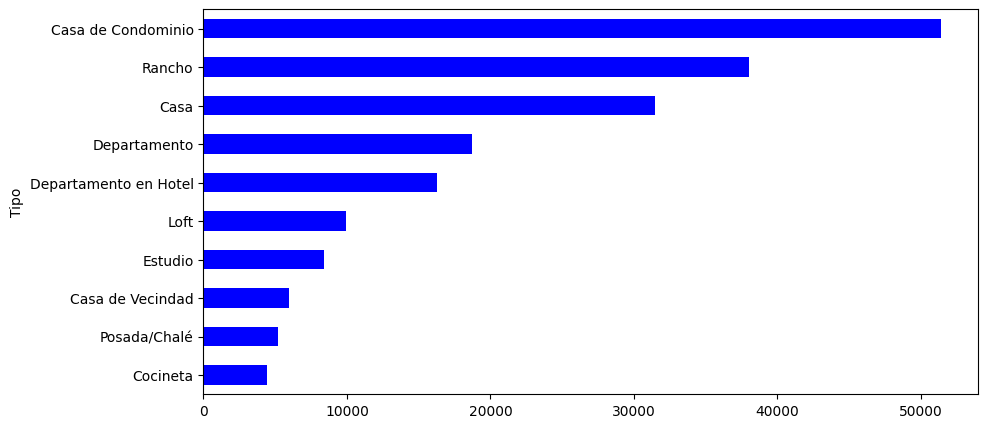

In [66]:
df_residencia = df_residencial.groupby('Tipo')['Valor'].mean().sort_values(ascending=True)
df_residencia.plot(kind = 'barh', figsize=(10,5),color = 'Blue')

In [67]:
df_residencial.Tipo.value_counts()

Tipo
Departamento             14764
Cocineta                   726
Casa de Condominio         610
Casa                       545
Departamento en Hotel      455
Casa de Vecindad           158
Loft                        38
Rancho                       8
Estudio                      4
Posada/Chalé                 1
Name: count, dtype: int64

In [68]:
df_residencial.query('Tipo == "Departamento"')
df_residencial.head()

,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
0,Cocineta,Condesa,1,0,0,40,5950.0,1750.0,210.0
1,Casa,Polanco,2,0,1,100,24500.0,NaN,NaN
3,Departamento,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0
4,Departamento,Del Valle,1,0,0,48,2800.0,805.0,NaN
5,Casa de Condominio,Santa Fe,5,4,5,750,77000.0,NaN,NaN


<Axes: xlabel='Tipo', ylabel='Frecuencia'>

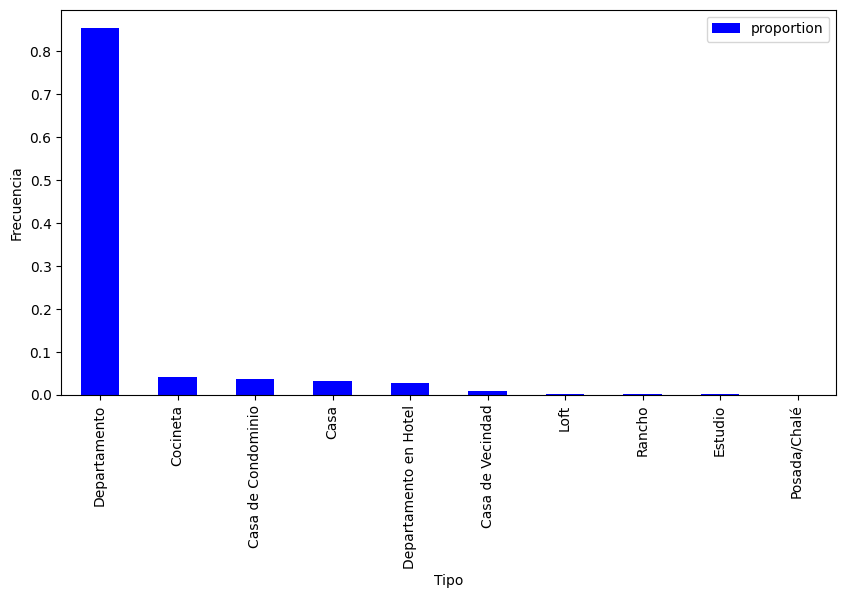

In [69]:
porcentaje_tipo = df_residencial.Tipo.value_counts(normalize=True).to_frame()
porcentaje_tipo.head()
porcentaje_tipo.plot(kind = 'bar', figsize=(10,5),color = 'Blue',xlabel='Tipo',ylabel='Frecuencia')



In [89]:
len(df['Colonia'].unique())

88

In [90]:
mean_habitaciones = df_residencial.groupby('Tipo')['Habitaciones'].mean().sort_values(ascending=False)
print(mean_habitaciones)

Tipo
Posada/Chalé             23.000000
Rancho                    5.125000
Casa de Condominio        4.319672
Casa                      3.359633
Departamento              2.504199
Casa de Vecindad          1.974684
Departamento en Hotel     1.419780
Loft                      1.078947
Cocineta                  0.836088
Estudio                   0.500000
Name: Habitaciones, dtype: float64


Colonia
San Juan Xalpa          420926.739130
Nativitas               244684.395062
La Merced               213292.770833
Santa Marta Acatitla    166048.105263
Villa de Cortés         135737.411765
                            ...      
Álvaro Obregón            3048.281250
San José Insurgentes      2660.000000
El Rodeo                  2586.111111
Tláhuac                   2481.818182
Las Aguilas               2222.500000
Name: Valor, Length: 88, dtype: float64


<Axes: title={'center': 'Valor promedio por colonia'}, xlabel='Colonia', ylabel='Valor promedio'>

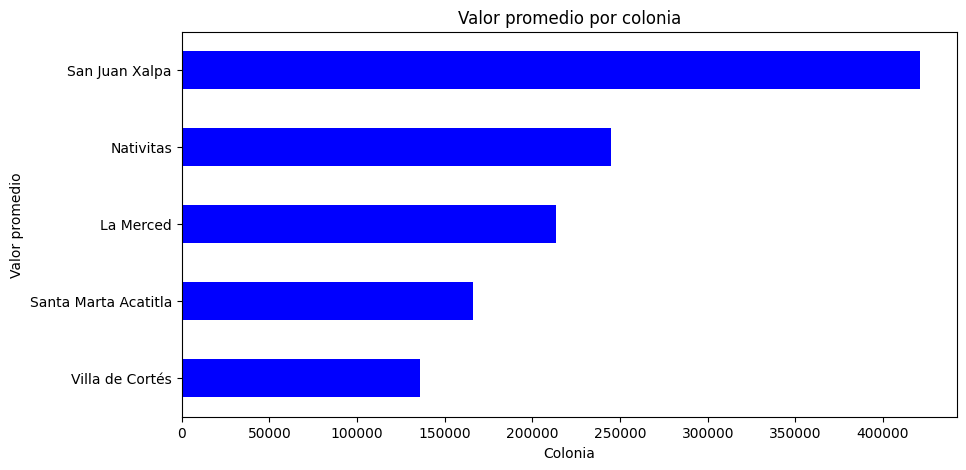

In [ ]:
df_colonias = df[['Colonia','Valor']]
df_colonias = df_colonias.groupby('Colonia')['Valor'].mean().sort_values(ascending=False)
print(df_colonias)
df_colonia = df_colonias.head(5)
df_colonia.sort_values(ascending=True).plot(kind = 'barh', figsize=(10,5),color = 'Blue',xlabel='Colonia',ylabel='Valor promedio',title='Valor promedio por colonia')
